# Exercícios (Téoricos e Prático): Modelagem da equação do calor e técnica de discretização
## PPG-Biometria
### Disciplina: Matemática Aplicada 
### Professor: Fernando Luiz Pio dos Santos
### Aluno: Vitor Eduardo Girotto Barelli

## Objetivos
- Resolver numericamente a equação do calor estacionária 1D por diferenças finitas;
- Comparar a solução numérica com a solução analítica;
- Analisar o erro da aproximação numérica;
- Resolver computacionalmente o exercício com \( f(x)=4\pi^2\sin(2\pi x) \)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parte 1: Quetões 2, 3 e 4

Resolver o problema de contorno

\[
-u''(x)=50, \qquad 0<x<1
\]

com condições de contorno

\[
u(0)=0, \qquad u(1)=0.
\]

Será usado o método de diferenças finitas com passo \(h=1/6\).

In [2]:
# Parâmetros do problema
f_const = 50
h = 1/6
k = 1

# Malha
x = np.arange(0, 1 + h, h)
n_internos = len(x) - 2

print("Nós da malha:", x)
print("Número de pontos internos:", n_internos)

Nós da malha: [0.         0.16666667 0.33333333 0.5        0.66666667 0.83333333
 1.         1.16666667]
Número de pontos internos: 6


A discretização por diferenças finitas centradas fornece o sistema

\[
-\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}=50,
\]

ou equivalentemente,

\[
-u_{i-1}+2u_i-u_{i+1}=50h^2.
\]

Isso gera um sistema linear da forma \(Au=b\).

In [3]:
# Matriz do sistema
A = 2*np.eye(n_internos) - np.eye(n_internos, k=1) - np.eye(n_internos, k=-1)

# Vetor do lado direito
b = (h**2 / k) * f_const * np.ones(n_internos)

print("Matriz A:")
print(A)

print("\nVetor b:")
print(b)

Matriz A:
[[ 2. -1.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0. -1.  2.]]

Vetor b:
[1.38888889 1.38888889 1.38888889 1.38888889 1.38888889 1.38888889]


## Resolução numérica do sistema

In [4]:
# Resolvendo o sistema linear
u_interno = np.linalg.solve(A, b)

# Adicionando as condições de contorno
u_numerica = np.zeros(len(x))
u_numerica[1:-1] = u_interno

print("Solução numérica nos pontos internos:")
for i, val in enumerate(u_interno, start=1):
    print(f"u_{i} = {val:.10f}")

print("\nSolução numérica completa:")
print(u_numerica)

Solução numérica nos pontos internos:
u_1 = 4.1666666667
u_2 = 6.9444444444
u_3 = 8.3333333333
u_4 = 8.3333333333
u_5 = 6.9444444444
u_6 = 4.1666666667

Solução numérica completa:
[0.         4.16666667 6.94444444 8.33333333 8.33333333 6.94444444
 4.16666667 0.        ]


## Solução analítica

A solução analítica do problema

\[
-u''(x)=50, \qquad u(0)=u(1)=0
\]

é

\[
u(x)=25x(1-x).
\]

In [5]:
# Solução analítica
def u_analitica(x):
    return 25 * x * (1 - x)

x_fino = np.linspace(0, 1, 400)
u_analitica_fina = u_analitica(x_fino)
u_analitica_nos = u_analitica(x)

## Comparação entre solução numérica e analítica

In [6]:
print("Comparação entre solução numérica e analítica:")
print("   x_i        u_numérica      u_analítica      erro absoluto")

for xi, un, ua in zip(x, u_numerica, u_analitica_nos):
    erro = abs(un - ua)
    print(f"{xi:7.4f}    {un:12.8f}    {ua:12.8f}    {erro:12.8e}")

Comparação entre solução numérica e analítica:
   x_i        u_numérica      u_analítica      erro absoluto
 0.0000      0.00000000      0.00000000    0.00000000e+00
 0.1667      4.16666667      3.47222222    6.94444444e-01
 0.3333      6.94444444      5.55555556    1.38888889e+00
 0.5000      8.33333333      6.25000000    2.08333333e+00
 0.6667      8.33333333      5.55555556    2.77777778e+00
 0.8333      6.94444444      3.47222222    3.47222222e+00
 1.0000      4.16666667      0.00000000    4.16666667e+00
 1.1667      0.00000000     -4.86111111    4.86111111e+00


## Gráfico da comparação

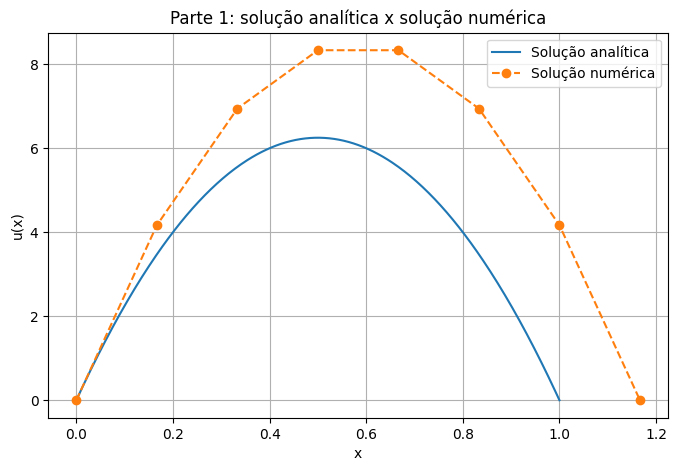

In [7]:
plt.figure(figsize=(8,5))
plt.plot(x_fino, u_analitica_fina, label='Solução analítica')
plt.plot(x, u_numerica, 'o--', label='Solução numérica')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Parte 1: solução analítica x solução numérica')
plt.grid(True)
plt.legend()
plt.show()

## Parte 2: Questões 4 e 5

Resolver numericamente o problema

\[
-u''(x)=4\pi^2\sin(2\pi x), \qquad 0<x<1
\]

com condições de contorno

\[
u(0)=0, \qquad u(1)=0,
\]

utilizando \(h=1/4\), e comparar com a solução exata

\[
u(x)=\sin(2\pi x).
\]

## Parâmetros da segunda parte

In [8]:
h2 = 1/4
x2 = np.arange(0, 1 + h2, h2)
x2_interno = x2[1:-1]
n2 = len(x2_interno)

print("Nós da malha:", x2)
print("Pontos internos:", x2_interno)

Nós da malha: [0.   0.25 0.5  0.75 1.  ]
Pontos internos: [0.25 0.5  0.75]


## Definição de f(x) e da solução exata

In [9]:
def f2(x):
    return 4 * np.pi**2 * np.sin(2 * np.pi * x)

def u_exata2(x):
    return np.sin(2 * np.pi * x)

## Sistema linear

In [10]:
A2 = 2*np.eye(n2) - np.eye(n2, k=1) - np.eye(n2, k=-1)
b2 = (h2**2) * f2(x2_interno)

print("Matriz A2:")
print(A2)

print("\nVetor b2:")
print(b2)

Matriz A2:
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]

Vetor b2:
[ 2.46740110e+00  3.02169486e-16 -2.46740110e+00]


## Resolução numérica

In [11]:
u2_interno = np.linalg.solve(A2, b2)

u2_numerica = np.zeros(len(x2))
u2_numerica[1:-1] = u2_interno

print("Solução numérica nos pontos internos:")
for i, val in enumerate(u2_interno, start=1):
    print(f"m_{i} = {val:.10f}")

print("\nSolução numérica completa:")
print(u2_numerica)

Solução numérica nos pontos internos:
m_1 = 1.2337005501
m_2 = 0.0000000000
m_3 = -1.2337005501

Solução numérica completa:
[ 0.00000000e+00  1.23370055e+00  2.96059473e-16 -1.23370055e+00
  0.00000000e+00]


## Solução exata

In [12]:
x2_fino = np.linspace(0, 1, 400)
u2_exata_fina = u_exata2(x2_fino)
u2_exata_nos = u_exata2(x2)

## Comparação e erro

In [13]:
erro2 = np.abs(u2_numerica - u2_exata_nos)

print("Comparação entre solução numérica e exata:")
print("   x_i        u_numérica      u_exata          erro absoluto")

for xi, un, ue, er in zip(x2, u2_numerica, u2_exata_nos, erro2):
    print(f"{xi:7.4f}    {un:12.8f}    {ue:12.8f}    {er:12.8e}")

Comparação entre solução numérica e exata:
   x_i        u_numérica      u_exata          erro absoluto
 0.0000      0.00000000      0.00000000    0.00000000e+00
 0.2500      1.23370055      1.00000000    2.33700550e-01
 0.5000      0.00000000      0.00000000    1.73594793e-16
 0.7500     -1.23370055     -1.00000000    2.33700550e-01
 1.0000      0.00000000     -0.00000000    2.44929360e-16


## Gráfico da comparação

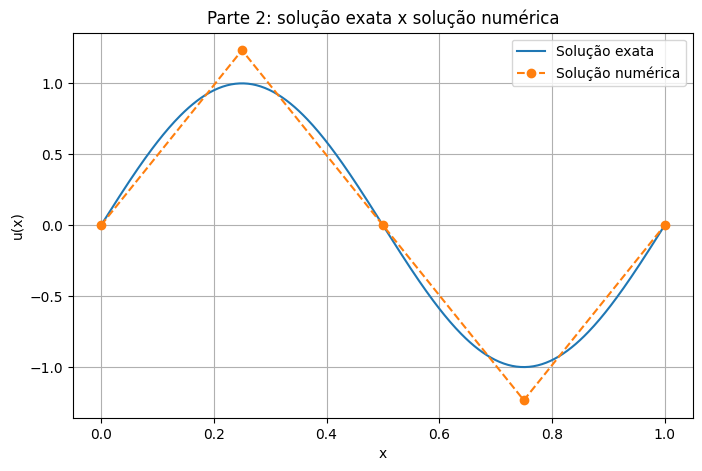

In [14]:
plt.figure(figsize=(8,5))
plt.plot(x2_fino, u2_exata_fina, label='Solução exata')
plt.plot(x2, u2_numerica, 'o--', label='Solução numérica')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Parte 2: solução exata x solução numérica')
plt.grid(True)
plt.legend()
plt.show()

## Gráfico do erro

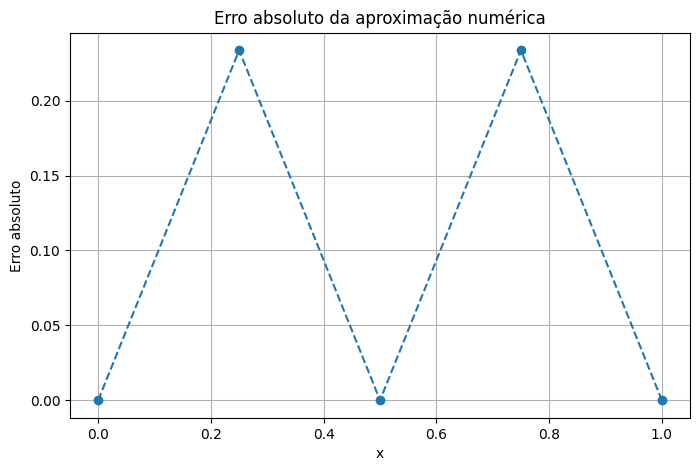

In [15]:
plt.figure(figsize=(8,5))
plt.plot(x2, erro2, 'o--')
plt.xlabel('x')
plt.ylabel('Erro absoluto')
plt.title('Erro absoluto da aproximação numérica')
plt.grid(True)
plt.show()